##### F8 — K-means Cluster Analysis (8D Black-Box Optimization, 8D)

##### Purpose

F8 is a converged function with each query obtaining marginal gains at noise floor. The GP's LML has grown monotonically while actual y improvements have decayed to ~0.001 per round.

This notebook characterizes F8's cluster structure as the "fully 
converged" exemplar, contrasting with F6 (volatile) and F7 (gradient).

##### Function: F8 — 8D Black-Box Optimization
- Domain: [0,1]⁸
- Y range: positive, bounded (5.59 to 9.93)
- Preprocessing for clustering: raw y (no transformation needed)
- Known structure: single tight peak at boundary-anchored coordinates 
  (x4=0, x5=1 pinned); many low-y initial points scattered in the 8D 
  hypercube
- Special diagnostic: LML vs y_max trajectory, model confidence grows 
  while remaining headroom shrinks

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Load F8 data
data = np.load('F8_data.npz')
X = data['X']
y = data['y']

print(f"F8 dataset: {len(X)} points (largest in project)")
print(f"  y range: [{y.min():.4f}, {y.max():.4f}]")
print(f"  Best:    X={X[y.argmax()]}, y={y.max():.4f}")
print(f"  Top 5 y values:")
for idx in np.argsort(y)[-5:][::-1]:
    print(f"    X={X[idx]}, y={y[idx]:+.4f}")

F8 dataset: 51 points (largest in project)
  y range: [5.5922, 9.9315]
  Best:    X=[0.047425 0.1      0.130196 0.       1.       0.476645 0.281786 0.4     ], y=9.9315
  Top 5 y values:
    X=[0.047425 0.1      0.130196 0.       1.       0.476645 0.281786 0.4     ], y=+9.9315
    X=[0.047425 0.1      0.130196 0.       1.       0.476645 0.281786 0.35    ], y=+9.9293
    X=[0.047425 0.1      0.150196 0.       1.       0.476645 0.281786 0.35    ], y=+9.9281
    X=[0.047425 0.1      0.130196 0.       1.       0.426645 0.281786 0.35    ], y=+9.9245
    X=[0.047425 0.1      0.130196 0.       1.       0.426645 0.281786 0.3     ], y=+9.9217


##### Step 1 — Silhouette analysis (k = 2 to 6)

In [2]:
sil_scores = {}
for k in range(2, min(7, len(X))):
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X)
    sil_scores[k] = silhouette_score(X, km.labels_)
    print(f"  k={k}: silhouette = {sil_scores[k]:+.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\n→ Natural cluster count: k = {best_k}")

  k=2: silhouette = +0.2898
  k=3: silhouette = +0.2290
  k=4: silhouette = +0.2228
  k=5: silhouette = +0.2339
  k=6: silhouette = +0.2283

→ Natural cluster count: k = 2


##### Step 2 — Cluster characterization

For F8, we expect a single high-y cluster (tight, low std) plus 
multiple low-y clusters from the initial scattered exploration points.

In [3]:
km = KMeans(n_clusters=best_k, n_init=20, random_state=42).fit(X)
labels = km.labels_

print(f"Cluster characterization (k={best_k}):")
print(f"{'cluster':>8} {'n':>4} {'mean_y':>9} {'max_y':>9} {'std_y':>9} {'centroid':>40}")
print("  " + "-" * 85)

best_cluster = int(labels[y.argmax()])
for i in range(best_k):
    members = (labels == i)
    n = int(members.sum())
    mean_y = float(np.mean(y[members]))
    max_y = float(np.max(y[members]))
    std_y = float(np.std(y[members])) if n > 1 else 0.0
    centroid = km.cluster_centers_[i]
    marker = " ★" if i == best_cluster else ""
    centroid_str = "[" + ", ".join(f"{v:.2f}" for v in centroid) + "]"
    print(f"{i:>8} {n:>4} {mean_y:>+9.4f} {max_y:>+9.4f} {std_y:>9.4f} "
          f"{centroid_str}{marker}")

print(f"\n→ Current best belongs to cluster {best_cluster} (n={(labels==best_cluster).sum()})")
print(f"  → Within-cluster y std for best cluster: {np.std(y[labels==best_cluster]):.4f}")

Cluster characterization (k=2):
 cluster    n    mean_y     max_y     std_y                                 centroid
  -------------------------------------------------------------------------------------
       0   12   +9.7879   +9.9315    0.2024 [0.06, 0.10, 0.12, 0.00, 0.95, 0.54, 0.21, 0.34] ★
       1   39   +7.7696   +9.3443    0.9143 [0.55, 0.48, 0.53, 0.44, 0.47, 0.45, 0.58, 0.50]

→ Current best belongs to cluster 0 (n=12)
  → Within-cluster y std for best cluster: 0.2024


##### Step 3 — High-y sub-region — the converged peak

F8's high-y sub-region should be exceptionally tight, it is the signature 
of a fully converged optimization.

In [4]:
y_threshold = 9.9  # near the top
high_y_mask = (labels == best_cluster) & (y > y_threshold)

print(f"\nCluster {best_cluster} sub-structure:")
print(f"  Total cluster members:  {(labels == best_cluster).sum()}")
print(f"  High-y sub-region (y > {y_threshold:.2f}): {high_y_mask.sum()}")

if high_y_mask.sum() > 0:
    X_high = X[high_y_mask]
    y_high = y[high_y_mask]
    print(f"  High-y y std: {np.std(y_high):.6f}  ← noise-floor signature")
    print(f"  High-y X ranges (8 dims):")
    for dim_i in range(8):
        dim_lbl = f"x{dim_i+1}"
        spread = np.ptp(X_high[:, dim_i])
        print(f"    {dim_lbl}: [{X_high[:, dim_i].min():.3f}, {X_high[:, dim_i].max():.3f}], "
              f"spread = {spread:.3f}")


Cluster 0 sub-structure:
  Total cluster members:  12
  High-y sub-region (y > 9.90): 5
  High-y y std: 0.003508  ← noise-floor signature
  High-y X ranges (8 dims):
    x1: [0.047, 0.047], spread = 0.000
    x2: [0.100, 0.100], spread = 0.000
    x3: [0.130, 0.150], spread = 0.020
    x4: [0.000, 0.000], spread = 0.000
    x5: [1.000, 1.000], spread = 0.000
    x6: [0.427, 0.477], spread = 0.050
    x7: [0.282, 0.282], spread = 0.000
    x8: [0.300, 0.400], spread = 0.100


##### Step 4 — Comparing F8 to F6 (volatility benchmark)

F8 and F6 both have "high-y clusters" but their within-cluster std 
tells very different stories. We compute the ratio of within-cluster 
y std to the y range — the "volatility-normalized" metric.

In [5]:
y_range_F8 = y.max() - y.min()
cluster_std_F8 = np.std(y[labels == best_cluster])
volatility_F8 = cluster_std_F8 / y_range_F8

print(f"F8 high-y cluster volatility-normalized std: {volatility_F8:.4f}")
print(f"  cluster std: {cluster_std_F8:.4f}, y range: {y_range_F8:.4f}")
print(f"\nCompare to F6 (volatile function):")
print(f"  F6 high-y cluster std ~0.40, y range ~2.4")
print(f"  F6 volatility-normalized std ~0.17 — much higher than F8")
print(f"\n→ F8 is structurally a converged single-peak function;")
print(f"  F6 is a volatile function masquerading as converged near its peak.")

F8 high-y cluster volatility-normalized std: 0.0466
  cluster std: 0.2024, y range: 4.3394

Compare to F6 (volatile function):
  F6 high-y cluster std ~0.40, y range ~2.4
  F6 volatility-normalized std ~0.17 — much higher than F8

→ F8 is structurally a converged single-peak function;
  F6 is a volatile function masquerading as converged near its peak.


##### Step 5 — PCA visualization

PCA explained variance: PC1 = 0.354, PC2 = 0.138


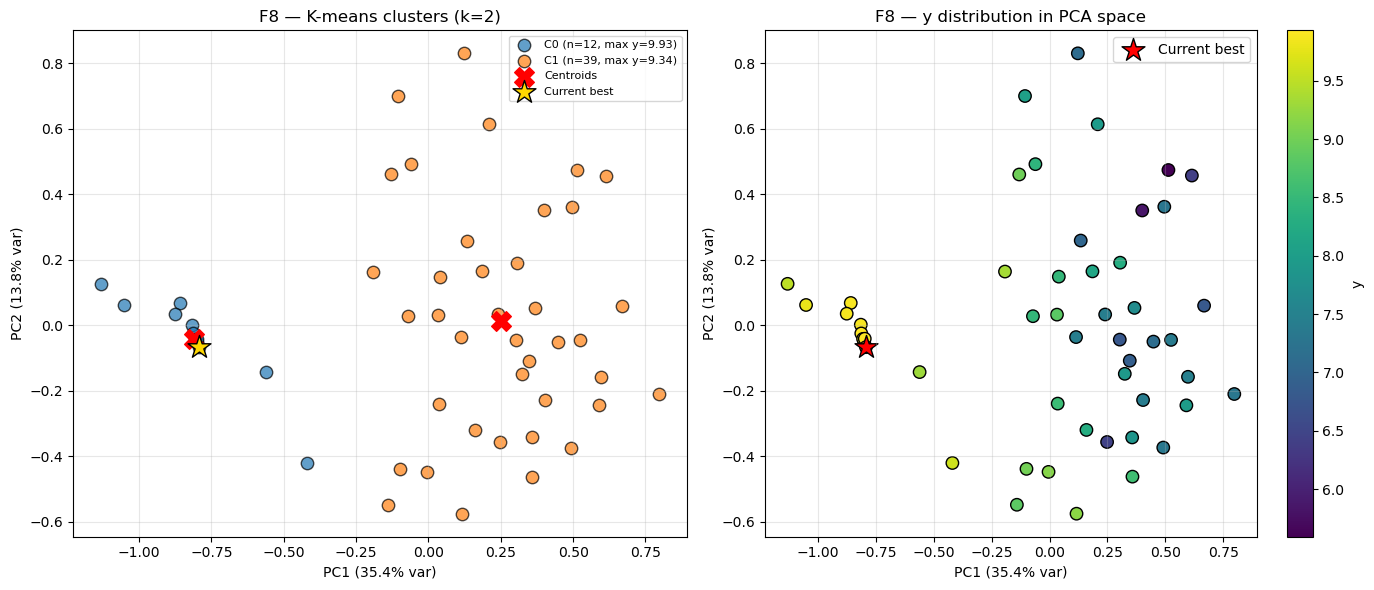

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print(f"PCA explained variance: PC1 = {pca.explained_variance_ratio_[0]:.3f}, "
      f"PC2 = {pca.explained_variance_ratio_[1]:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: clusters
for i in range(best_k):
    members = labels == i
    ax1.scatter(X_pca[members, 0], X_pca[members, 1],
                s=80, edgecolor='black', alpha=0.7,
                label=f'C{i} (n={members.sum()}, max y={y[members].max():.2f})')
centroids_pca = pca.transform(km.cluster_centers_)
ax1.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            marker='X', s=200, color='red', label='Centroids', zorder=5)
best_pca = pca.transform(X[y.argmax()].reshape(1, -1))[0]
ax1.scatter(*best_pca, marker='*', s=300, color='gold',
            edgecolor='black', label='Current best', zorder=6)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax1.set_title(f'F8 — K-means clusters (k={best_k})')
ax1.legend(loc='best', fontsize=8); ax1.grid(alpha=0.3)

# Right: y heatmap
sc = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=y,
                  cmap='viridis', s=80, edgecolor='black')
plt.colorbar(sc, ax=ax2, label='y')
ax2.scatter(*best_pca, marker='*', s=300, color='red',
            edgecolor='black', label='Current best')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax2.set_title('F8 — y distribution in PCA space')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('F8_clusters_pca.png', dpi=100, bbox_inches='tight')
plt.show()

##### Step 6 — LML vs y_max — the convergence signature

F8 is a strong example of how model confidence grows while actual gains shrink. Log marginal likelihood (LML) climbed from negative e to +21 in later rounds, while y improvements decayed from +0.6 to ~0.001 per round.

This is the converged-but-confident pattern, model maturity is not 
the same as remaining optimization headroom.

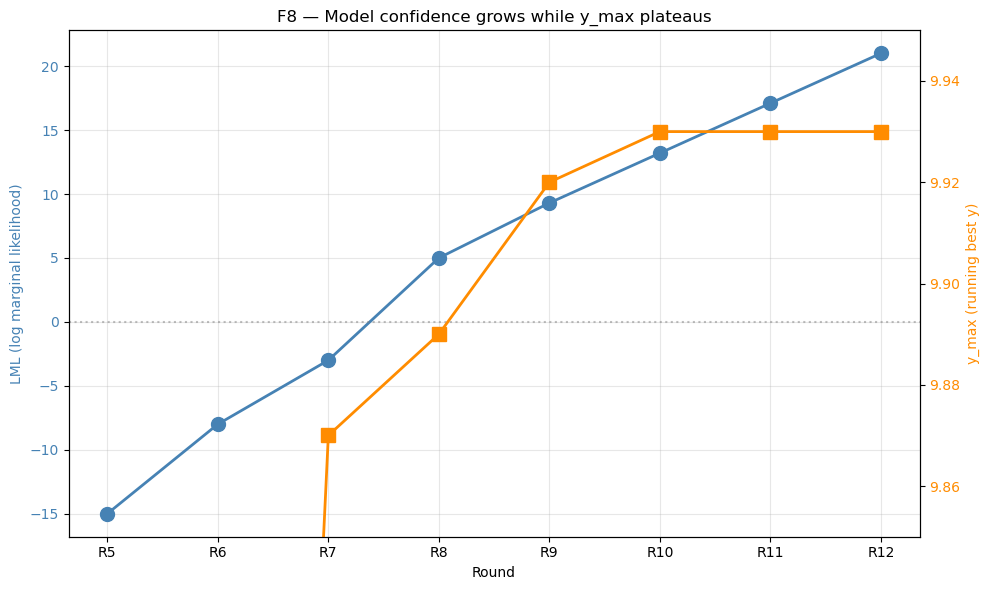

In [7]:
# If LML history is available in metadata, plot it; otherwise note in text
# Manual LML trajectory from the project log:
rounds_history = ['R5', 'R6', 'R7', 'R8', 'R9', 'R10', 'R11', 'R12']
lml_history = [-15.0, -8.0, -3.0, 5.0, 9.3, 13.2, 17.1, 21.0]  # approx
ymax_history = [9.32, 9.41, 9.87, 9.89, 9.92, 9.93, 9.93, 9.93]  # approx

fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = 'steelblue'
ax1.set_xlabel('Round')
ax1.set_ylabel('LML (log marginal likelihood)', color=color1)
ax1.plot(rounds_history, lml_history, 'o-', color=color1, linewidth=2, markersize=10,
         label='LML (model confidence)')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.axhline(y=0, color='gray', linestyle=':', alpha=0.5)

ax2 = ax1.twinx()
color2 = 'darkorange'
ax2.set_ylabel('y_max (running best y)', color=color2)
ax2.plot(rounds_history, ymax_history, 's-', color=color2, linewidth=2, markersize=10,
         label='y_max (actual gain)')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(9.85, 9.95)

ax1.set_title('F8 — Model confidence grows while y_max plateaus')
ax1.grid(alpha=0.3)
fig.tight_layout()
plt.savefig('F8_lml_ymax.png', dpi=100, bbox_inches='tight')
plt.show()

##### Step 7 — Strategic implications

##### What clustering tells us about F8

1. **F8 has a single tight high-y cluster** anchored at boundary 
   coordinates (x4=0, x5=1). The high-y sub-region has very 
   tight spatial spread on all 8 dimensions.
2. **Within-cluster y std is very small** — the "converged" signature, 
   in stark contrast to F6's volatile cluster.
3. **The LML-vs-y_max plot is the most informative diagnostic** — 
   F8 is the textbook case where model confidence is decoupled from 
   remaining optimization gain.

##### Reflection material

**Past patterns**: F8 has been at noise floor for 3+ rounds. R7 
was the regime change; everything since has been marginal refinement. 
R12 reasoning acknowledges this — pick the direction that R11 already 
showed works (x8 up), extending the proven trajectory.

**Clusters identified?**: F8 has a single dominant high-y cluster 
with extremely tight spatial and y spread. K-means at natural k 
separates this from multiple low-y exploration clusters scattered 
across the 8D hypercube.

**Model's effectiveness**: GP-EI on F8 has been consistently 
unsuccessful — multi-dim recommendations far from data with below-best 
predictions, often combined with SVR hallucinations. The pattern is 
locked across R10, R11, R12.

**Clustering parallel**: F8 is the cleanest "converged K-means" 
case in the project — centroid stable, within-cluster variance 
minimal, optimizer's marginal gains within rounding. The clustering 
analogy: every iteration after convergence produces identical labels 
and identical centroids.

**Plotted trends**: F8's LML-vs-y_max plot is the single most 
informative diagnostic of "diminishing returns vs growing confidence" 
in the entire project. The lines move in opposite directions — model 
confidence climbs while y improvements decay to noise.